In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv('data/features.csv')
df.head()

,date,home_team,away_team,home_GF5,home_GA5,home_W5,home_D5,home_L5,home_points5,home_mean_competition5,home_matches_used5,away_GF5,away_GA5,away_W5,away_D5,away_L5,away_points5,away_mean_competition5,away_matches_used5,home_GF10,home_GA10,home_points10,home_mean_competition10,home_matches_used10,away_GF10,away_GA10,away_points10,away_mean_competition10,away_matches_used10,home_elo,away_elo,elo_diff,home_win_streak,away_win_streak,home_unbeaten_streak,away_unbeaten_streak,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_matches,neutral,competition_level,home_score,away_score
0,2000-01-04,Egypt,Togo,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,0,1,2.0,1.0
1,2000-01-07,Tunisia,Togo,0.0,0.0,0,0,0,0,0.0,0,1.0,2.0,0,0,1,0,1.0,1,0.0,0.0,0,0.0,0,1.0,2.0,0,1.0,1,1500.0,1495.0,5.0,0,0,0,0,0,0,0,0,0,1,7.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,0,1,0.0,0.0
3,2000-01-09,Mexico,Iran,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0,0,0,0.0,0,0.0,0.0,0,0.0,0,0.0,0.0,0,0.0,0,1500.0,1500.0,0.0,0,0,0,0,0,0,0,0,1,1,2.0,1.0
4,2000-01-09,Ivory Coast,Egypt,0.0,0.0,0,0,0,0,0.0,0,2.0,1.0,1,0,0,3,1.0,1,0.0,0.0,0,0.0,0,2.0,1.0,3,1.0,1,1500.0,1505.0,-5.0,0,1,0,1,0,0,0,0,0,1,2.0,0.0


In [4]:
df.tail()

,date,home_team,away_team,home_GF5,home_GA5,home_W5,home_D5,home_L5,home_points5,home_mean_competition5,home_matches_used5,away_GF5,away_GA5,away_W5,away_D5,away_L5,away_points5,away_mean_competition5,away_matches_used5,home_GF10,home_GA10,home_points10,home_mean_competition10,home_matches_used10,away_GF10,away_GA10,away_points10,away_mean_competition10,away_matches_used10,home_elo,away_elo,elo_diff,home_win_streak,away_win_streak,home_unbeaten_streak,away_unbeaten_streak,h2h_home_wins,h2h_away_wins,h2h_draws,h2h_matches,neutral,competition_level,home_score,away_score
25338,2026-06-09,Liberia,Sierra Leone,0.6,1.4,0,2,3,2,1.8,5,1.2,0.6,3,1,1,10,2.4,5,1.0,1.5,9,2.4,10,1.1,0.9,15,2.7,10,1414.715497,1457.315001,-42.599504,0,1,0,3,4,4,1,9,0,1,3.0,1.0
25339,2026-06-10,Portugal,Nigeria,2.6,0.8,3,1,1,10,1.8,5,2.2,1.0,3,2,0,11,1.4,5,2.6,1.0,21,2.5,10,2.0,0.6,22,3.2,10,1839.739806,1745.237357,94.502450,2,0,4,10,1,0,0,1,0,1,2.0,1.0
25340,2026-06-10,Bolivia,Algeria,1.2,1.6,2,0,3,6,1.8,5,1.8,0.4,3,1,1,10,2.6,5,0.8,1.7,10,1.5,10,1.9,0.4,23,3.2,10,1528.265175,1744.511065,-216.245890,0,1,0,3,0,1,0,1,1,1,0.0,4.0
25341,2026-06-10,England,Costa Rica,1.2,0.4,3,1,1,10,1.8,5,0.6,2.2,0,2,3,2,1.8,5,2.2,0.5,22,2.0,10,1.3,1.8,9,2.6,10,1856.466253,1669.175765,187.290488,1,0,1,0,1,0,1,2,1,1,3.0,0.0
25342,2026-06-10,Afghanistan,Pakistan,0.4,0.8,1,2,2,5,2.6,5,1.2,1.2,2,2,1,8,2.6,5,0.4,1.4,5,2.2,10,0.6,2.2,8,2.8,10,1364.177601,1274.055836,90.121765,0,2,0,2,1,4,2,7,1,2,0.0,2.0


In [5]:
df.shape

(25343, 44)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25343 entries, 0 to 25342
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     25343 non-null  str    
 1   home_team                25343 non-null  str    
 2   away_team                25343 non-null  str    
 3   home_GF5                 25343 non-null  float64
 4   home_GA5                 25343 non-null  float64
 5   home_W5                  25343 non-null  int64  
 6   home_D5                  25343 non-null  int64  
 7   home_L5                  25343 non-null  int64  
 8   home_points5             25343 non-null  int64  
 9   home_mean_competition5   25343 non-null  float64
 10  home_matches_used5       25343 non-null  int64  
 11  away_GF5                 25343 non-null  float64
 12  away_GA5                 25343 non-null  float64
 13  away_W5                  25343 non-null  int64  
 14  away_D5                  25343 no

In [7]:
df["date"] = pd.to_datetime(df["date"])

In [8]:
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,25343,2013-04-25 01:34:53.406463,2000-01-04 00:00:00,2006-10-11 00:00:00,2013-02-06 00:00:00,2019-10-12 00:00:00,2026-06-10 00:00:00,NaN
home_GF5,25343.0,1.390523,0.0,0.8,1.2,1.8,13.6,0.862194
home_GA5,25343.0,1.340385,0.0,0.8,1.2,1.75,19.0,0.939862
home_W5,25343.0,1.920254,0.0,1.0,2.0,3.0,5.0,1.264796
home_D5,25343.0,1.143235,0.0,0.0,1.0,2.0,5.0,0.966082
home_L5,25343.0,1.847098,0.0,1.0,2.0,3.0,5.0,1.302646
home_points5,25343.0,6.903997,0.0,4.0,7.0,10.0,15.0,3.619399
home_mean_competition5,25343.0,2.40261,0.0,1.8,2.2,3.0,6.0,0.879354
home_matches_used5,25343.0,4.910587,0.0,5.0,5.0,5.0,5.0,0.569784
away_GF5,25343.0,1.348693,0.0,0.8,1.2,1.8,21.0,0.846475


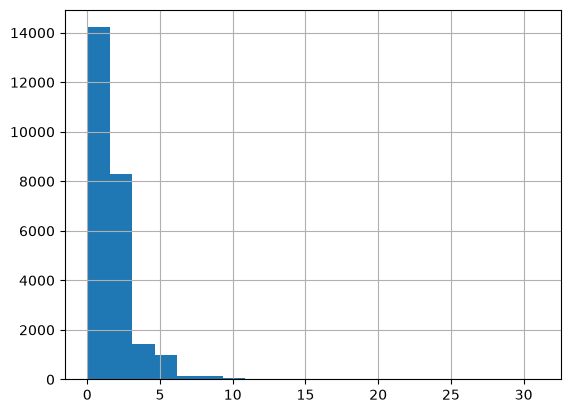

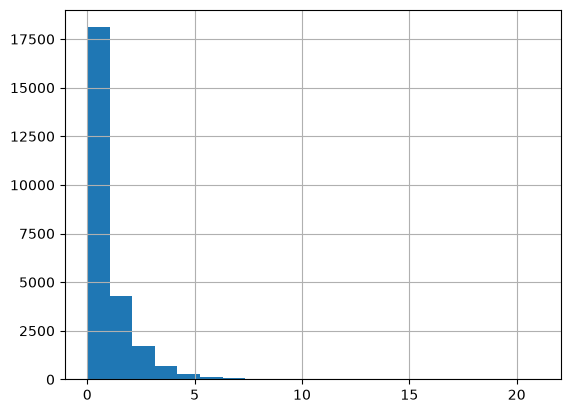

In [10]:
df["home_score"].hist(bins=20)
plt.show()

df["away_score"].hist(bins=20)
plt.show()

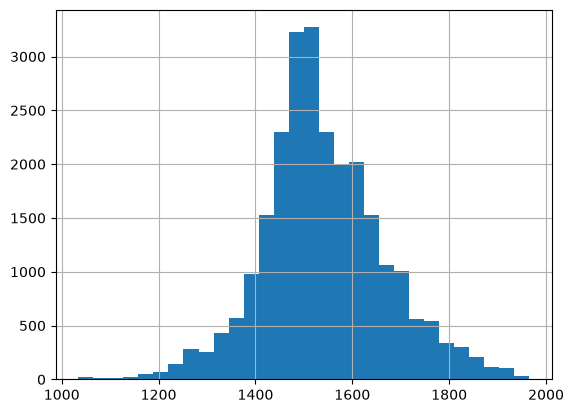

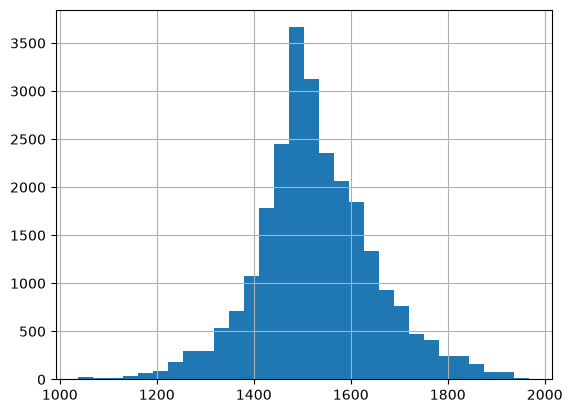

In [11]:
df["home_elo"].hist(bins=30)
plt.show()

df["away_elo"].hist(bins=30)
plt.show()

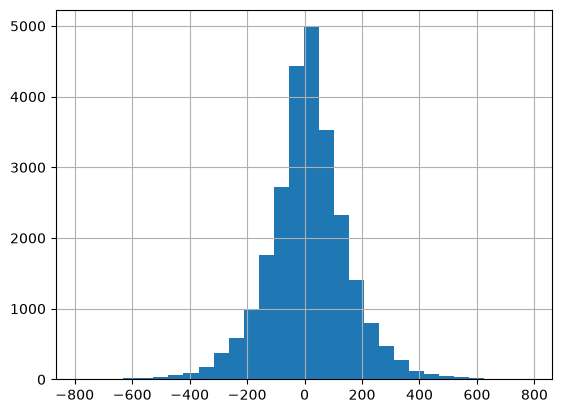

In [12]:
df["elo_diff"].hist(bins=30)
plt.show()

In [13]:
corr = df.corr(numeric_only=True)

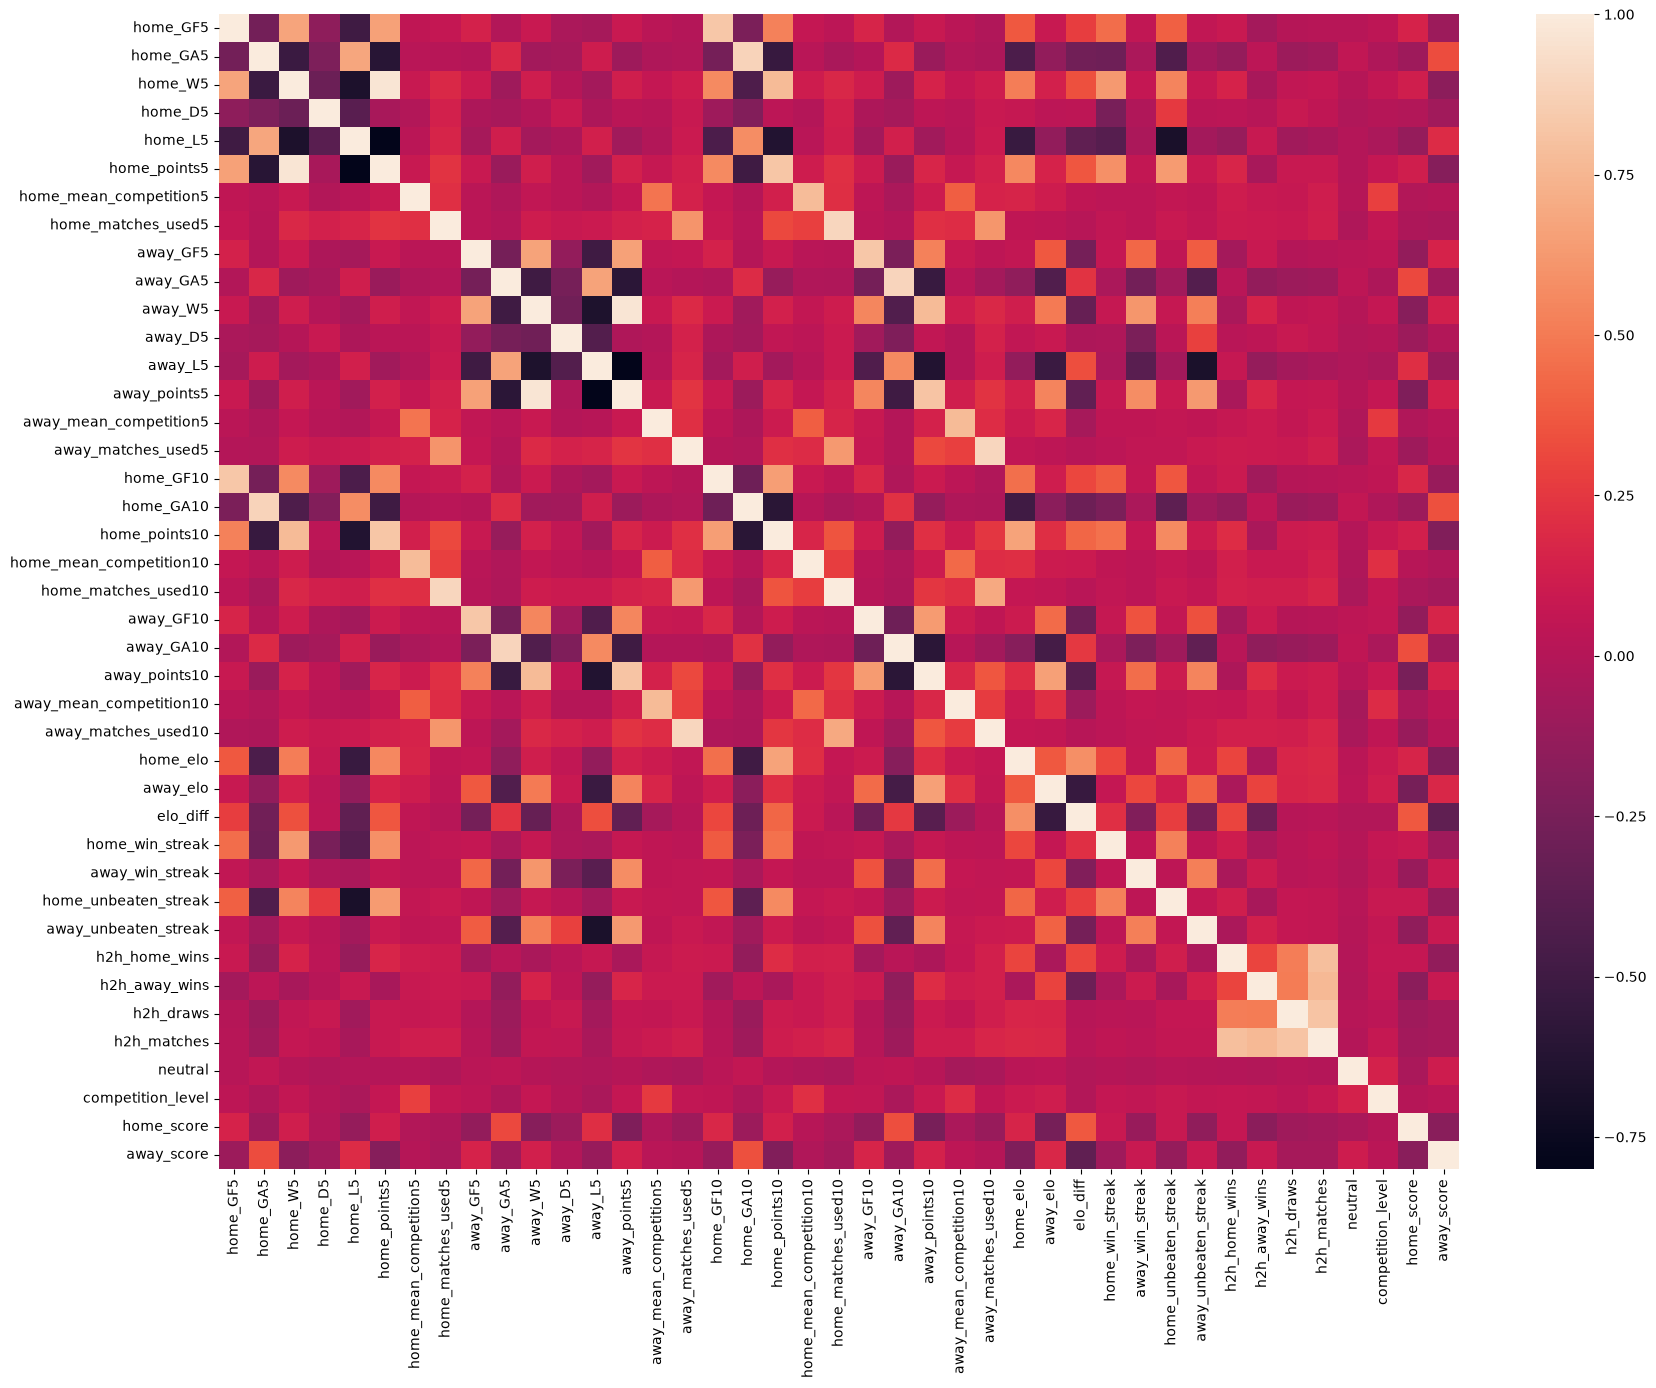

In [14]:
import seaborn as sns

plt.figure(figsize=(20,15))
sns.heatmap(corr)
plt.show()

In [15]:
corr["home_score"].sort_values()

away_elo                  -0.254546
away_points10             -0.251013
away_points5              -0.222707
away_W5                   -0.187527
away_score                -0.179620
h2h_away_wins             -0.171167
away_unbeaten_streak      -0.148886
away_GF10                 -0.144630
away_GF5                  -0.134497
home_L5                   -0.125296
away_win_streak           -0.112889
away_matches_used10       -0.112119
away_D5                   -0.100041
home_GA10                 -0.097768
home_GA5                  -0.097001
away_matches_used5        -0.091317
h2h_draws                 -0.089335
h2h_matches               -0.074192
neutral                   -0.047245
home_matches_used10       -0.035149
away_mean_competition10   -0.034464
home_matches_used5        -0.030297
away_mean_competition5    -0.018267
home_mean_competition5    -0.012078
home_D5                   -0.008329
competition_level          0.005864
home_mean_competition10    0.014241
h2h_home_wins              0

In [16]:
corr["away_score"].sort_values()

elo_diff                  -0.351599
home_elo                  -0.217952
home_points10             -0.216060
home_points5              -0.190090
home_score                -0.179620
home_W5                   -0.160867
h2h_home_wins             -0.146315
home_unbeaten_streak      -0.127574
away_L5                   -0.116196
home_GF10                 -0.115592
home_GF5                  -0.102536
away_GA10                 -0.089920
home_win_streak           -0.088242
away_GA5                  -0.083172
home_D5                   -0.080348
home_matches_used10       -0.067781
h2h_draws                 -0.061859
h2h_matches               -0.055303
home_matches_used5        -0.044146
home_mean_competition10   -0.015688
away_D5                   -0.008693
away_matches_used10        0.002709
home_mean_competition5     0.003481
away_matches_used5         0.005166
away_mean_competition5     0.016458
competition_level          0.022798
away_mean_competition10    0.037039
h2h_away_wins              0

In [17]:
df.to_csv('data/features_processed.csv', index=False)